# Time-Varying Break-Even Employment Growth In Statsmodels

This notebook uses unemployment changes `U` on the left-hand side and employment growth `E` on the right-hand side.

The specification mirrors notebooks 05 and 07:

U_t = c_t + b_0 E_t + b_1 E_{t-1} + b_2 E_{t-2} + g_2 D_{2020Q2,t} + g_3 D_{2020Q3,t} + eps_t

with

c_t = c_{t-1} + eta_t

The state innovation variance is constrained to `sigma2.level = (0.05 * sigma_ols)^2`.

The implied break-even series is now the employment growth rate that keeps predicted unemployment change at zero.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm

PROJECT_ROOT = Path.cwd()
DATA_PATH = PROJECT_ROOT / 'data' / 'prepared' / 'analysis_dataset_quarterly.csv'
OUTPUT_PATH = PROJECT_ROOT / 'outputs' / 'time_varying_break_even_statsmodels_U_on_E.csv'

## Load Dataset

In [2]:
analysis_df = pd.read_csv(DATA_PATH, parse_dates=['date'])
analysis_df = analysis_df.sort_values('date').reset_index(drop=True)

state_df = analysis_df.loc[:, ['date', 'U', 'E']].copy()
state_df['E_lag1'] = state_df['E'].shift(1)
state_df['E_lag2'] = state_df['E'].shift(2)
state_df['d2020q2'] = (state_df['date'] == pd.Timestamp('2020-04-01')).astype(float)
state_df['d2020q3'] = (state_df['date'] == pd.Timestamp('2020-07-01')).astype(float)
state_df = state_df.dropna().reset_index(drop=True)
state_df.head()

,date,U,E,E_lag1,E_lag2,d2020q2,d2020q3
0,1992-07-01,0.459021,-1.132308,-0.146517,-0.297662,0.0,0.0
1,1992-10-01,0.586024,-0.847614,-1.132308,-0.146517,0.0,0.0
2,1993-01-01,0.505504,-0.839623,-0.847614,-1.132308,0.0,0.0
3,1993-04-01,0.544153,0.812695,-0.839623,-0.847614,0.0,0.0
4,1993-07-01,0.405117,-0.310166,0.812695,-0.839623,0.0,0.0


## Static OLS Benchmark

In [3]:
X_ols = sm.add_constant(state_df[['E', 'E_lag1', 'E_lag2', 'd2020q2', 'd2020q3']])
ols_result = sm.OLS(state_df['U'], X_ols).fit()
sigma_ols = float(ols_result.resid.std(ddof=int(ols_result.df_model) + 1))
std_eta_fixed = 0.05 * sigma_ols
sigma2_level_fixed = std_eta_fixed ** 2
sum_beta = float(ols_result.params['E'] + ols_result.params['E_lag1'] + ols_result.params['E_lag2'])
static_break_even_qoq = -float(ols_result.params['const']) / sum_beta
static_break_even_annualized = ((1 + static_break_even_qoq / 100) ** 4 - 1) * 100

pd.DataFrame({
    'parameter': ['const', 'b0', 'b1', 'b2', 'g2', 'g3', 'sigma_ols', 'std_eta_fixed', 'static_break_even_qoq', 'static_break_even_annualized'],
    'estimate': [
        float(ols_result.params['const']),
        float(ols_result.params['E']),
        float(ols_result.params['E_lag1']),
        float(ols_result.params['E_lag2']),
        float(ols_result.params['d2020q2']),
        float(ols_result.params['d2020q3']),
        sigma_ols,
        std_eta_fixed,
        static_break_even_qoq,
        static_break_even_annualized,
    ],
})

,parameter,estimate
0,const,0.085573
1,b0,-0.183699
2,b1,-0.153233
3,b2,-0.041138
4,g2,0.602152
5,g3,-0.207351
6,sigma_ols,0.167634
7,std_eta_fixed,0.008382
8,static_break_even_qoq,0.226343
9,static_break_even_annualized,0.908449


## Statsmodels Local-Level Specification

As in the other time-varying notebooks, the slope coefficients are fixed while the intercept follows a constrained local-level process.

In [4]:
exog = state_df[['E', 'E_lag1', 'E_lag2', 'd2020q2', 'd2020q3']]

ucm = sm.tsa.UnobservedComponents(
    state_df['U'],
    level='local level',
    exog=exog,
)

start_params = ucm.start_params.copy()
param_names = list(ucm.param_names)
name_to_idx = {name: idx for idx, name in enumerate(param_names)}

for name, value in {
    'sigma2.level': sigma2_level_fixed,
    'beta.E': float(ols_result.params['E']),
    'beta.E_lag1': float(ols_result.params['E_lag1']),
    'beta.E_lag2': float(ols_result.params['E_lag2']),
    'beta.d2020q2': float(ols_result.params['d2020q2']),
    'beta.d2020q3': float(ols_result.params['d2020q3']),
}.items():
    if name in name_to_idx:
        start_params[name_to_idx[name]] = value

fixed_params = {'sigma2.level': sigma2_level_fixed}
with ucm.fix_params(fixed_params):
    ucm_result = ucm.fit(start_params=start_params, disp=False, includes_fixed=True)

print(ucm_result.summary())

                        Unobserved Components Results                         
Dep. Variable:                      U   No. Observations:                  134
Model:                    local level   Log Likelihood                  52.819
Date:                Mon, 01 Jun 2026   AIC                            -93.638
Time:                        09:59:32   BIC                            -76.296
Sample:                             0   HQIC                           -86.591
                                - 134                                         
Covariance Type:                  opg                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
sigma2.irregular         0.0238      0.002     10.675      0.000       0.019       0.028
sigma2.level (fixed)  7.025e-05        nan        nan        nan         nan         nan
beta.E      

In [5]:
param_table = pd.DataFrame({
    'parameter': ucm_result.param_names,
    'estimate': ucm_result.params,
})
param_table

,parameter,estimate
sigma2.irregular,sigma2.irregular,0.023783
sigma2.level,sigma2.level (fixed),0.000070
beta.E,beta.E,-0.202145
beta.E_lag1,beta.E_lag1,-0.172420
beta.E_lag2,beta.E_lag2,-0.062094
beta.d2020q2,beta.d2020q2,0.563733
beta.d2020q3,beta.d2020q3,-0.238658


## Smoothed Level And Implied Break-Even Employment Growth

In [6]:
smoothed_level = pd.Series(ucm_result.level.smoothed, index=state_df.index)

beta_cols = ['beta.E', 'beta.E_lag1', 'beta.E_lag2']
sum_beta_ucm = float(sum(ucm_result.params[col] for col in beta_cols))

results_df = state_df.copy()
results_df['c_t'] = smoothed_level
results_df['break_even_employment_growth_qoq_pct'] = -results_df['c_t'] / sum_beta_ucm
results_df['break_even_employment_growth_annualized_pct'] = ((1 + results_df['break_even_employment_growth_qoq_pct'] / 100) ** 4 - 1) * 100
results_df['static_break_even_qoq_pct'] = static_break_even_qoq
results_df['static_break_even_annualized_pct'] = static_break_even_annualized

results_df[['c_t', 'break_even_employment_growth_qoq_pct', 'break_even_employment_growth_annualized_pct']].describe().T

,count,mean,std,min,25%,50%,75%,max
c_t,134.0,0.098902,0.036587,0.028077,0.074441,0.111125,0.127146,0.137389
break_even_employment_growth_qoq_pct,134.0,0.226497,0.083789,0.064299,0.170478,0.254490,0.291180,0.314637
break_even_employment_growth_annualized_pct,134.0,0.909492,0.337037,0.257444,0.683658,1.021854,1.169816,1.264502


## Scenario Paths

In [7]:
employment_growth_1pct_annualized_qoq = ((1 + 0.01) ** 0.25 - 1) * 100

results_df['implied_U_if_E_0_qoq_pp'] = results_df['c_t']
results_df['implied_U_if_E_1pct_ann_qoq_pp'] = results_df['c_t'] + sum_beta_ucm * employment_growth_1pct_annualized_qoq

pd.DataFrame({
    'scenario': ['Employment stagnation', 'Employment growth at 1% annualised'],
    'assumed_E_qoq_pct': [0.0, employment_growth_1pct_annualized_qoq],
    'mean_implied_U_change_pp': [
        results_df['implied_U_if_E_0_qoq_pp'].mean(),
        results_df['implied_U_if_E_1pct_ann_qoq_pp'].mean(),
    ],
})

,scenario,assumed_E_qoq_pct,mean_implied_U_change_pp
0,Employment stagnation,0.000000,0.098902
1,Employment growth at 1% annualised,0.249068,-0.009856


## Plots

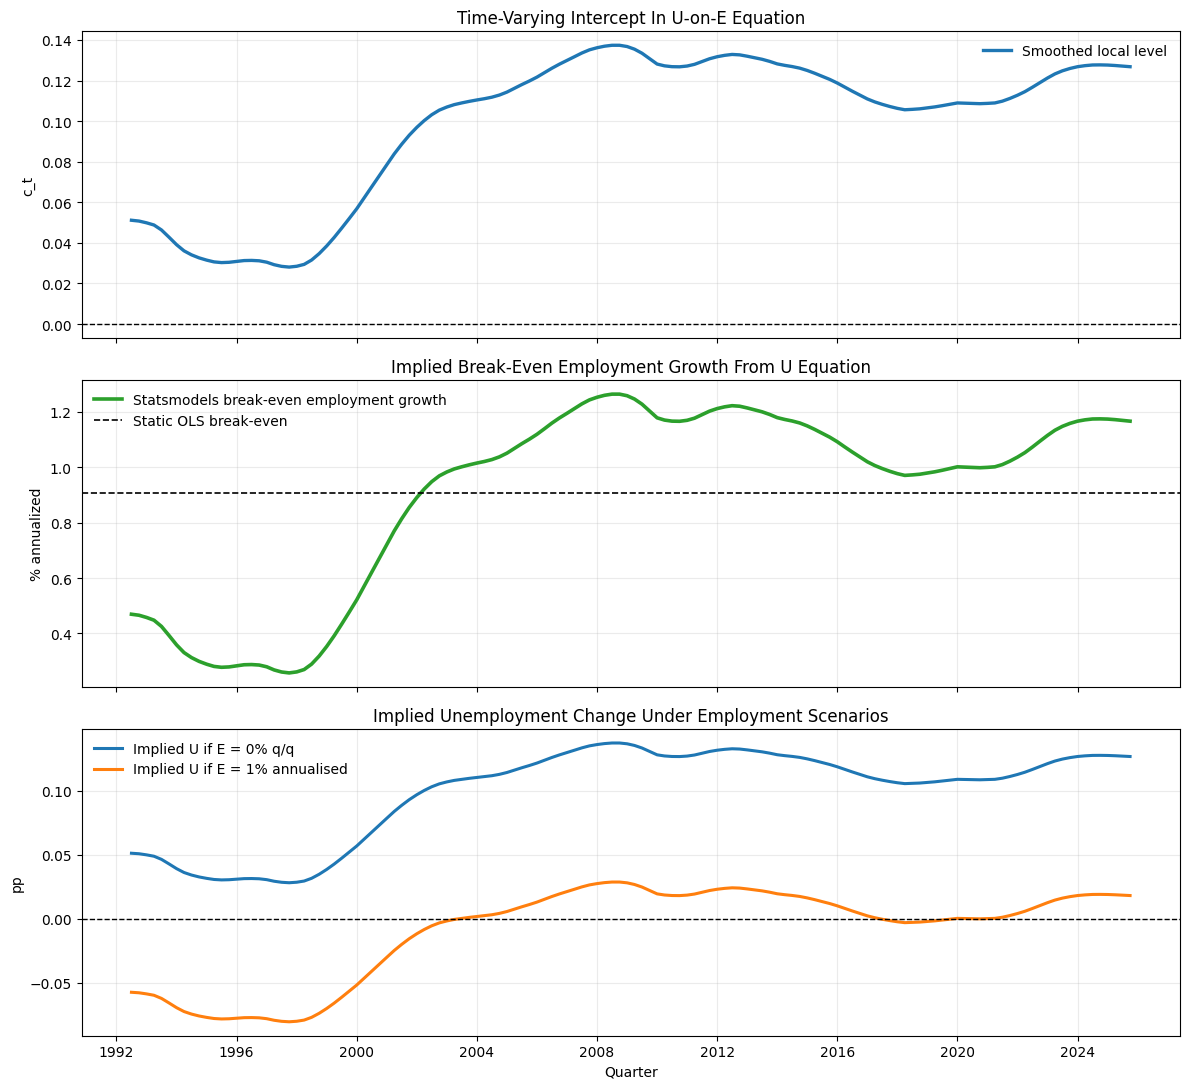

In [8]:
fig, axes = plt.subplots(3, 1, figsize=(12, 11), sharex=True)
axes[0].plot(results_df['date'], results_df['c_t'], color='tab:blue', linewidth=2.4, label='Smoothed local level')
axes[0].axhline(0, color='black', linestyle='--', linewidth=1.0)
axes[0].set_title('Time-Varying Intercept In U-on-E Equation')
axes[0].set_ylabel('c_t')
axes[0].grid(alpha=0.25)
axes[0].legend(frameon=False)

axes[1].plot(results_df['date'], results_df['break_even_employment_growth_annualized_pct'], color='tab:green', linewidth=2.6, label='Statsmodels break-even employment growth')
axes[1].axhline(static_break_even_annualized, color='black', linestyle='--', linewidth=1.2, label='Static OLS break-even')
axes[1].set_title('Implied Break-Even Employment Growth From U Equation')
axes[1].set_ylabel('% annualized')
axes[1].grid(alpha=0.25)
axes[1].legend(frameon=False)

axes[2].plot(results_df['date'], results_df['implied_U_if_E_0_qoq_pp'], linewidth=2.2, label='Implied U if E = 0% q/q')
axes[2].plot(results_df['date'], results_df['implied_U_if_E_1pct_ann_qoq_pp'], linewidth=2.2, label='Implied U if E = 1% annualised')
axes[2].axhline(0, color='black', linestyle='--', linewidth=1.0)
axes[2].set_title('Implied Unemployment Change Under Employment Scenarios')
axes[2].set_ylabel('pp')
axes[2].set_xlabel('Quarter')
axes[2].grid(alpha=0.25)
axes[2].legend(frameon=False)

plt.tight_layout()
plt.show()

## Save Results

In [9]:
OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
results_df.to_csv(OUTPUT_PATH, index=False)
OUTPUT_PATH

PosixPath('/Users/christianhepenstrick/codex_projects/swiss-labour-break-even-rates/outputs/time_varying_break_even_statsmodels_U_on_E.csv')